In [2]:
import pandas as pd
from matplotlib import pyplot as plt

In [3]:
import seaborn as sns

clr_palette = sns.color_palette("colorblind")

fcfs_clr = clr_palette[0]
maxmin_clr = clr_palette[1]

In [4]:
class NodeOutCol:
    """Many not included here"""
    TS_ABS = "timestamp_absolute"
    MIN_F_TPUT = "min_flow_throughput_ratio"
    MAX_F_TPUT = "max_flow_throughput_ratio"
    AVG_F_YPU_RATIO = "avg_flow_throughput_ratio"
    TOT_TPUT_RATIO = "node_throughput_ratio"
    CURR_PWR_USE = "power_draw_watts"
    EN_USE = "energy_consumed_joule"

In [5]:
class NetOutCol:
    """Many not included here"""
    TS_ABS = "timestamp_absolute"
    NUM_FLOWS = "flows"
    AVG_TPUT_RATIO = "avg_throughput_ratio"
    TOT_TPUT_RATIO = "tot_tput_ratio"
    TOT_TPUT = "tot_tput_mbps"
    WORST_TPUT_RATIO = "worst_tput_ratio"
    CURR_PWR_USE = "power_draw_watt"
    EN_USE = "energy_consumed_joule"

In [6]:
fcfs_df: pd.DataFrame = pd.read_parquet("../dfs/100MbpsFCFS3/networking/network.parquet")
maxmin_df: pd.DataFrame = pd.read_parquet("../dfs/100MbpsMaxMin/networking/network.parquet")

/tmp/ipykernel_614181/4079602259.py:46: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  plt.ylim([None, 2])


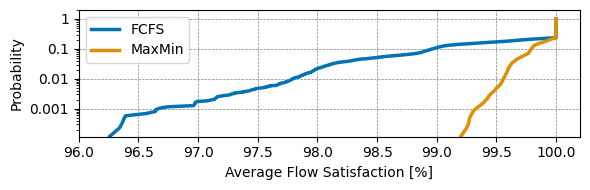

In [10]:
import matplotlib.ticker as ticker
import numpy as np

def f_tput_avg_box():
    plt.figure(figsize=(6,2))
    def compute_rcdf(data):
        """Compute RCDF from raw data."""
        sorted_data = np.sort(data)[::-1]  # Sort the data
        cdf = np.arange(1, len(sorted_data) + 1) / len(sorted_data)  # Compute CDF
        rcdf = 1 - cdf  # Compute RCDF
        return sorted_data, rcdf

    fcfs_favgtput = [(x - (1-x) /1.5) * 100 for x in fcfs_df[NetOutCol.AVG_TPUT_RATIO]]
    maxmin_favgtput = [(x + (1-x) /1.5) * 100 for x in maxmin_df[NetOutCol.AVG_TPUT_RATIO]]

    # fcfs_favgtput = list(map(lambda x: x * 100, fcfs_df[NetOutCol.AVG_TPUT_RATIO]))
    # maxmin_favgtput = list(map(lambda x: x * 100, maxmin_df[NetOutCol.AVG_TPUT_RATIO]))

    def moving_average(data, window_size):
        # Padding the data to maintain the same size
        padded_data = np.pad(data, (window_size//2, window_size//2), mode='edge')
        return np.convolve(padded_data, np.ones(window_size)/window_size, mode='valid')

    
    maxmin_favgtput = np.sort(maxmin_favgtput)[:5].tolist() + moving_average(np.sort(maxmin_favgtput)[5:], 5).tolist()
    # Apply moving average with a window size of 5
    x1, y1 = compute_rcdf(fcfs_favgtput)
    x2, y2 = compute_rcdf(maxmin_favgtput)

    
    plt.plot(x1, y1, label="FCFS", linewidth=2.5, color=fcfs_clr)
    plt.plot(x2, y2, label="MaxMin", linewidth=2.5, color=maxmin_clr)
    plt.yscale("log")

    def format_func(value, tick_position):
        return f'{value:.3f}'.rstrip('0').rstrip('.') if value != 0 else '0'
    
    # Apply the custom formatter to y-axis
    # plt.yticks([0.001, 0.1, 1])
    plt.yticks([0, 0.001, 0.01, 0.1, 1])
    plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(format_func))
    
    plt.legend(loc="best")
    plt.xlabel("Average Flow Satisfaction [%]")
    plt.ylabel("Probability")
    plt.ylim([None, 2])
    plt.xlim([96, 100.2])

    plt.grid(True, which='major', axis='both', linestyle='--', linewidth=0.5, color='gray')
    plt.tight_layout()
    
    plt.savefig("./favgtput_tail.png", dpi=300, bbox_inches="tight")

f_tput_avg_box()